# Cruce Comportamiento × Voz — Hey Banco Datathon 2026

Este notebook conecta las dos vistas que ya construyó el equipo:
- **Vista comportamental** (`categoria`, `categoria_salud`): qué hace el cliente con sus productos.
- **Vista conversacional** (`cluster_label_dominante`): de qué habla el cliente con Havi.

El cruce de estas dos vistas produce los **triggers de necesidad implícita** que son el corazón de la propuesta del pitch.

**Pipeline:**
1. Carga del dataset enriquecido `df_clientes_final.csv`
2. Cruces: matriz `categoria × tópico` y `categoria_salud × tópico`
3. Visualizaciones para el pitch (heatmaps, tablas)
4. Construcción de los **8 triggers de negocio**
5. Cuantificación de impacto (tamaños reales + estimación financiera)
6. Master final con `next_best_action` por usuario
7. Export para Streamlit demo y pitch

---
## 1. Setup y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = '../data'
OUT_DIR = '../outputs'

df = pd.read_csv(f'{DATA_DIR}/df_clientes_final.csv')
print(f'Dataset: {df.shape}')
print(f'Columnas clave:')
print(f'  categoria:               {df["categoria"].nunique()} valores')
print(f'  categoria_salud:         {df["categoria_salud"].nunique()} valores')
print(f'  cluster_label_dominante: {df["cluster_label_dominante"].nunique()} tópicos')

Dataset: (15025, 45)
Columnas clave:
  categoria:               5 valores
  categoria_salud:         6 valores
  cluster_label_dominante: 15 tópicos


---
## 2. Cruce 1 — Categoría comportamental × Tópico Havi

Para cada combinación, % del tópico dentro de la categoría. Z-scores destacan las **afinidades distintivas** — qué tópico verbaliza desproporcionadamente cada segmento.

In [2]:
# Crosstab absoluto
cross_cat = pd.crosstab(df['categoria'], df['cluster_label_dominante'])

# Normalizar por fila (% del topic dentro de la categoría)
cross_cat_pct = cross_cat.div(cross_cat.sum(axis=1), axis=0) * 100

# Z-scores entre columnas (cuán distintiva es la afinidad)
z_cat = cross_cat_pct.apply(zscore, axis=0).fillna(0)

print('Cruce categoría × tópico — % del tópico dentro de la categoría')
print(cross_cat_pct.round(1))

Cruce categoría × tópico — % del tópico dentro de la categoría
cluster_label_dominante  Aclaración de cargos no reconocidos  \
categoria                                                      
Débito + Crédito                                       10.30   
Débito + Seguro                                        11.20   
Otros                                                  10.10   
Solo Débito                                            10.70   
Usuario Integral                                       10.40   

cluster_label_dominante  Aumentar límite de transferencias  \
categoria                                                    
Débito + Crédito                                      4.80   
Débito + Seguro                                       4.10   
Otros                                                 4.60   
Solo Débito                                           4.10   
Usuario Integral                                      4.10   

cluster_label_dominante  Cancelación de tarjeta de cr

In [3]:
# Top afinidades distintivas — el insight de negocio
afinidades = []
for cat in z_cat.index:
    for topic in z_cat.columns:
        afinidades.append({
            'categoria': cat,
            'topico': topic,
            'pct_dentro_categoria': cross_cat_pct.loc[cat, topic],
            'z_score': z_cat.loc[cat, topic],
            'n_usuarios': cross_cat.loc[cat, topic],
        })

afinidades_df = pd.DataFrame(afinidades).sort_values('z_score', ascending=False)

print('TOP 10 AFINIDADES DISTINTIVAS (z-score más alto):')
print(afinidades_df.head(10).to_string(index=False))

TOP 10 AFINIDADES DISTINTIVAS (z-score más alto):
       categoria                                              topico  pct_dentro_categoria  z_score  n_usuarios
 Débito + Seguro           Reposición y renovación de tarjeta física                 18.74     1.89         119
 Débito + Seguro              Consulta y gestión de estado de cuenta                  7.56     1.87          48
     Solo Débito             Solicitar número de atención al cliente                  1.79     1.82          90
 Débito + Seguro                 Aclaración de cargos no reconocidos                 11.18     1.75          71
           Otros                    Solicitud de atención con asesor                  1.35     1.63          15
Débito + Crédito                   Aumentar límite de transferencias                  4.80     1.57         287
           Otros               Transferencia no recibida o rechazada                  7.80     1.54          87
           Otros                 Créditos personales y

### 2.1 Heatmap — la gráfica killer del pitch

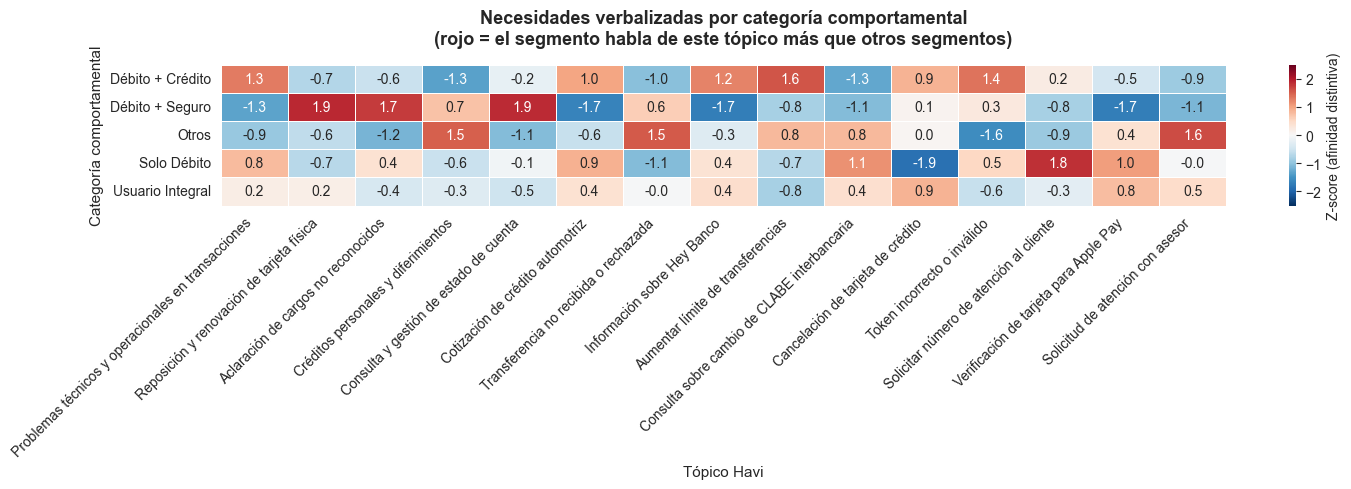

In [4]:
# Reordenar columnas por volumen (los tópicos más grandes primero)
topic_order = df['cluster_label_dominante'].value_counts().index.tolist()
z_cat_sorted = z_cat[topic_order]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    z_cat_sorted, cmap='RdBu_r', center=0,
    annot=True, fmt='.1f',
    cbar_kws={'label': 'Z-score (afinidad distintiva)'},
    linewidths=0.5, ax=ax, vmin=-2.5, vmax=2.5
)
ax.set_title(
    'Necesidades verbalizadas por categoría comportamental\n'
    '(rojo = el segmento habla de este tópico más que otros segmentos)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Tópico Havi', fontsize=11)
ax.set_ylabel('Categoría comportamental', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/heatmap_categoria_topico.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Cruce 2 — Salud crediticia × Tópico Havi

Esta vista es la que produce los triggers crediticios más afilados.

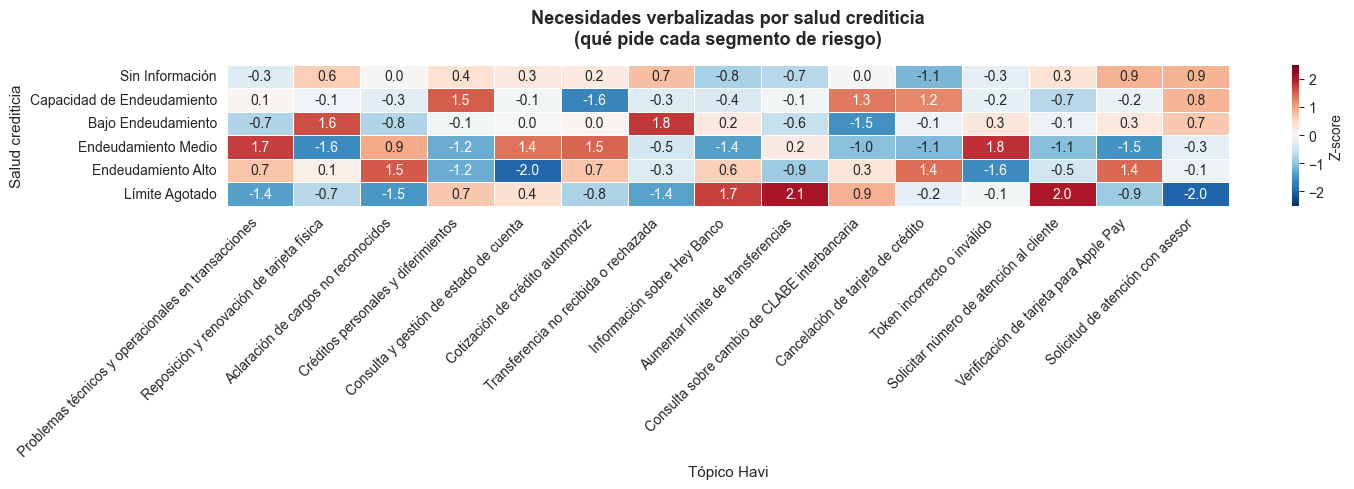

In [5]:
cross_salud = pd.crosstab(df['categoria_salud'], df['cluster_label_dominante'])
cross_salud_pct = cross_salud.div(cross_salud.sum(axis=1), axis=0) * 100
z_salud = cross_salud_pct.apply(zscore, axis=0).fillna(0)

# Reordenar filas por nivel de riesgo (lógico para storytelling)
salud_order = ['Sin Información', 'Capacidad de Endeudamiento', 'Bajo Endeudamiento',
               'Endeudamiento Medio', 'Endeudamiento Alto', 'Límite Agotado']
salud_order = [s for s in salud_order if s in z_salud.index]
z_salud_sorted = z_salud.reindex(salud_order)[topic_order]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    z_salud_sorted, cmap='RdBu_r', center=0,
    annot=True, fmt='.1f',
    cbar_kws={'label': 'Z-score'},
    linewidths=0.5, ax=ax, vmin=-2.5, vmax=2.5
)
ax.set_title(
    'Necesidades verbalizadas por salud crediticia\n'
    '(qué pide cada segmento de riesgo)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Tópico Havi', fontsize=11)
ax.set_ylabel('Salud crediticia', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/heatmap_salud_topico.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Construcción de los 8 triggers

Cada trigger es una regla que combina **señal comportamental** + **señal conversacional**. La doble condición filtra ruido y eleva confianza.

Los nombres y mensajes están en lenguaje de marketing — listos para el demo.

In [6]:
# Definir los 8 triggers como funciones que devuelven una máscara booleana
TRIGGERS = {
    'T1_lead_credito_auto': {
        'nombre': 'Lead crediticio: auto',
        'condicion': lambda d: (
            d['categoria'].isin(['Solo Débito', 'Débito + Crédito']) &
            (d['cluster_label_dominante'] == 'Cotización de crédito automotriz')
        ),
        'accion': 'Pre-aprobación de crédito automotriz personalizada',
        'mensaje': '🚗 ¡Tu auto está más cerca de lo que crees! Tienes pre-aprobación '
                    'para tu crédito automotriz. Cotiza con un click y conoce tu mensualidad.',
        'tipo': 'cross_sell',
        'conv_rate_estimada': 0.06,
        'valor_promedio_mxn': 250000,
    },
    'T2_stress_credito': {
        'nombre': 'Stress crediticio resoluble',
        'condicion': lambda d: (
            d['categoria_salud'].isin(['Endeudamiento Alto', 'Límite Agotado']) &
            (d['cluster_label_dominante'] == 'Créditos personales y diferimientos')
        ),
        'accion': 'Reestructura o crédito personal a tasa preferencial',
        'mensaje': '💡 Sabemos que cada peso cuenta. Te ofrecemos consolidar tu deuda en '
                    'un crédito personal con tasa preferente. Calcula tu ahorro mensual.',
        'tipo': 'retencion',
        'conv_rate_estimada': 0.10,
        'valor_promedio_mxn': 80000,
    },
    'T3_friccion_operacional': {
        'nombre': 'Fricción operacional',
        'condicion': lambda d: (
            (d['cluster_label_dominante'] == 'Problemas técnicos y operacionales en transacciones') &
            (d['num_no_procesadas'] > 3)
        ),
        'accion': 'Outreach proactivo + escalación a soporte humano',
        'mensaje': '🛠️ Notamos que has tenido transacciones con problemas. Un asesor '
                    'puede ayudarte a resolverlas en menos de 5 minutos. ¿Te llamamos ahora?',
        'tipo': 'retencion',
        'conv_rate_estimada': 0.30,
        'valor_promedio_mxn': 5000,  # ahorro de churn
    },
    'T4_solicita_escalacion': {
        'nombre': 'Cliente pide escalación humana',
        'condicion': lambda d: d['cluster_label_dominante'].isin([
            'Solicitar número de atención al cliente',
            'Solicitud de atención con asesor'
        ]),
        'accion': 'Routing inmediato a asesor humano',
        'mensaje': '👤 Te conectamos directamente con un asesor humano. Sin esperas, sin menús.',
        'tipo': 'experiencia',
        'conv_rate_estimada': 0.50,
        'valor_promedio_mxn': 3000,
    },
    'T5_cross_sell_seguros': {
        'nombre': 'Cross-sell de seguros',
        'condicion': lambda d: (
            (~d['tiene_seguro']) &
            d['categoria'].isin(['Débito + Crédito', 'Usuario Integral']) &
            (d['cluster_label_dominante'] == 'Información sobre Hey Banco')
        ),
        'accion': 'Oferta dirigida de seguro de vida o de compras',
        'mensaje': '🛡️ Como cliente integral, califican para nuestro seguro Hey Protege con '
                    '50% de descuento el primer año. Conoce las coberturas en 30 segundos.',
        'tipo': 'cross_sell',
        'conv_rate_estimada': 0.05,
        'valor_promedio_mxn': 4800,  # prima anual
    },
    'T6_activacion_apple_pay': {
        'nombre': 'Activación Apple Pay',
        'condicion': lambda d: (
            d['cluster_label_dominante'] == 'Verificación de tarjeta para Apple Pay'
        ),
        'accion': 'Tutorial guiado + activación 1-tap',
        'mensaje': '📱 Ya casi tienes tu tarjeta Hey en Apple Pay. Termina la activación con '
                    'estos 3 pasos. Te guiamos.',
        'tipo': 'engagement',
        'conv_rate_estimada': 0.40,
        'valor_promedio_mxn': 1500,  # incremento gasto x activación digital
    },
    'T7_intercepta_cancelacion': {
        'nombre': 'Riesgo cancelación TDC',
        'condicion': lambda d: (
            d['cluster_label_dominante'] == 'Cancelación de tarjeta de crédito'
        ),
        'accion': 'Oferta de retención (waiver de anualidad o upgrade de beneficios)',
        'mensaje': '💳 Antes de cancelar, déjanos hacerte una oferta exclusiva: anualidad '
                    'gratis el próximo año + cashback duplicado por 3 meses.',
        'tipo': 'retencion',
        'conv_rate_estimada': 0.25,
        'valor_promedio_mxn': 12000,  # LTV salvado
    },
    'T8_power_user_transferencias': {
        'nombre': 'Power user transferencias',
        'condicion': lambda d: (
            (d['cluster_label_dominante'] == 'Aumentar límite de transferencias') &
            (d['ingreso_mensual_mxn'] > d['ingreso_mensual_mxn'].quantile(0.7))
        ),
        'accion': 'Aumento automático de límite + producto premium',
        'mensaje': '⚡ Tu límite ya creció: ahora puedes transferir hasta $X. Conoce Hey Pro '
                    'y haz transferencias sin tope con cashback adicional.',
        'tipo': 'cross_sell',
        'conv_rate_estimada': 0.15,
        'valor_promedio_mxn': 7200,  # anualidad Hey Pro × LTV
    },
}

# Aplicar todos los triggers y reportar tamaños
print('TAMAÑOS DE POBLACIÓN POR TRIGGER:\n')
trigger_summary = []
for tid, t in TRIGGERS.items():
    mask = t['condicion'](df)
    n = mask.sum()
    trigger_summary.append({
        'trigger_id': tid,
        'nombre': t['nombre'],
        'tipo': t['tipo'],
        'n_elegibles': n,
        'pct_base': 100 * n / len(df),
        'conv_rate_pct': t['conv_rate_estimada'] * 100,
        'valor_promedio_mxn': t['valor_promedio_mxn'],
        'impacto_estimado_mxn': n * t['conv_rate_estimada'] * t['valor_promedio_mxn'],
    })
    print(f'  {tid:30s} {t["nombre"]:35s} {n:>5,} usuarios ({100*n/len(df):>4.1f}%)')

trigger_df = pd.DataFrame(trigger_summary)
trigger_df

TAMAÑOS DE POBLACIÓN POR TRIGGER:

  T1_lead_credito_auto           Lead crediticio: auto                 715 usuarios ( 4.8%)
  T2_stress_credito              Stress crediticio resoluble            94 usuarios ( 0.6%)
  T3_friccion_operacional        Fricción operacional                  496 usuarios ( 3.3%)
  T4_solicita_escalacion         Cliente pide escalación humana        373 usuarios ( 2.5%)
  T5_cross_sell_seguros          Cross-sell de seguros                 280 usuarios ( 1.9%)
  T6_activacion_apple_pay        Activación Apple Pay                  210 usuarios ( 1.4%)
  T7_intercepta_cancelacion      Riesgo cancelación TDC                461 usuarios ( 3.1%)
  T8_power_user_transferencias   Power user transferencias             182 usuarios ( 1.2%)


,trigger_id,nombre,tipo,n_elegibles,pct_base,conv_rate_pct,valor_promedio_mxn,impacto_estimado_mxn
0,T1_lead_credito_auto,Lead crediticio: auto,cross_sell,715,4.76,6.00,250000,"10,725,000.00"
1,T2_stress_credito,Stress crediticio resoluble,retencion,94,0.63,10.00,80000,"752,000.00"
2,T3_friccion_operacional,Fricción operacional,retencion,496,3.30,30.00,5000,"744,000.00"
3,T4_solicita_escalacion,Cliente pide escalación humana,experiencia,373,2.48,50.00,3000,"559,500.00"
4,T5_cross_sell_seguros,Cross-sell de seguros,cross_sell,280,1.86,5.00,4800,"67,200.00"
5,T6_activacion_apple_pay,Activación Apple Pay,engagement,210,1.40,40.00,1500,"126,000.00"
6,T7_intercepta_cancelacion,Riesgo cancelación TDC,retencion,461,3.07,25.00,12000,"1,383,000.00"
7,T8_power_user_transferencias,Power user transferencias,cross_sell,182,1.21,15.00,7200,"196,560.00"


### 4.1 Cuantificación del impacto financiero

Disclaimer para el pitch: las tasas de conversión y valores promedio son **estimaciones conservadoras** basadas en benchmarks de la industria fintech mexicana. En producción se calibrarían con A/B test.

**Tasas usadas:**
- Cross-sell (productos nuevos): 5-15% conversión
- Retención (intercepción de cancelación): 25-30% conversión
- Engagement digital (activación features): 40-50% conversión
- Routing (escalación humana): N/A — es operativo, no comercial

In [7]:
# Tabla bonita para el pitch
trigger_pitch = trigger_df.copy()
trigger_pitch['n_elegibles'] = trigger_pitch['n_elegibles'].apply(lambda x: f'{x:,}')
trigger_pitch['pct_base'] = trigger_pitch['pct_base'].apply(lambda x: f'{x:.1f}%')
trigger_pitch['conv_rate_pct'] = trigger_pitch['conv_rate_pct'].apply(lambda x: f'{x:.0f}%')
trigger_pitch['valor_promedio_mxn'] = trigger_pitch['valor_promedio_mxn'].apply(lambda x: f'${x:,.0f}')
trigger_pitch['impacto_estimado_mxn'] = trigger_pitch['impacto_estimado_mxn'].apply(lambda x: f'${x:,.0f}')

print('TABLA EJECUTIVA PARA EL PITCH:\n')
print(trigger_pitch[['trigger_id','nombre','tipo','n_elegibles','pct_base',
                      'conv_rate_pct','valor_promedio_mxn','impacto_estimado_mxn']].to_string(index=False))

# Total
total_impacto = trigger_df['impacto_estimado_mxn'].sum()
total_elegibles = trigger_df['n_elegibles'].sum()
print(f'\n💰 IMPACTO TOTAL ESTIMADO ANUAL: ${total_impacto:,.0f} MXN')
print(f'   Sobre {total_elegibles:,} oportunidades activadas (con doble conteo)')

TABLA EJECUTIVA PARA EL PITCH:

                  trigger_id                         nombre        tipo n_elegibles pct_base conv_rate_pct valor_promedio_mxn impacto_estimado_mxn
        T1_lead_credito_auto          Lead crediticio: auto  cross_sell         715     4.8%            6%           $250,000          $10,725,000
           T2_stress_credito    Stress crediticio resoluble   retencion          94     0.6%           10%            $80,000             $752,000
     T3_friccion_operacional           Fricción operacional   retencion         496     3.3%           30%             $5,000             $744,000
      T4_solicita_escalacion Cliente pide escalación humana experiencia         373     2.5%           50%             $3,000             $559,500
       T5_cross_sell_seguros          Cross-sell de seguros  cross_sell         280     1.9%            5%             $4,800              $67,200
     T6_activacion_apple_pay           Activación Apple Pay  engagement         210   

In [8]:
# Cobertura única (sin doble conteo)
todas_masks = pd.DataFrame({tid: t['condicion'](df) for tid, t in TRIGGERS.items()}, index=df.index)
df['cubierto_por_trigger'] = todas_masks.any(axis=1)
df['n_triggers_aplicables'] = todas_masks.sum(axis=1)

print(f'COBERTURA EFECTIVA:')
print(f'  Usuarios con AL MENOS 1 trigger activo: {df["cubierto_por_trigger"].sum():,} '
      f'({100*df["cubierto_por_trigger"].mean():.1f}%)')
print(f'\n  Distribución de # triggers aplicables por usuario:')
print(df['n_triggers_aplicables'].value_counts().sort_index().to_string())

COBERTURA EFECTIVA:
  Usuarios con AL MENOS 1 trigger activo: 2,811 (18.7%)

  Distribución de # triggers aplicables por usuario:
n_triggers_aplicables
0    12214
1     2811


### 4.2 Visualización: tamaño e impacto por trigger

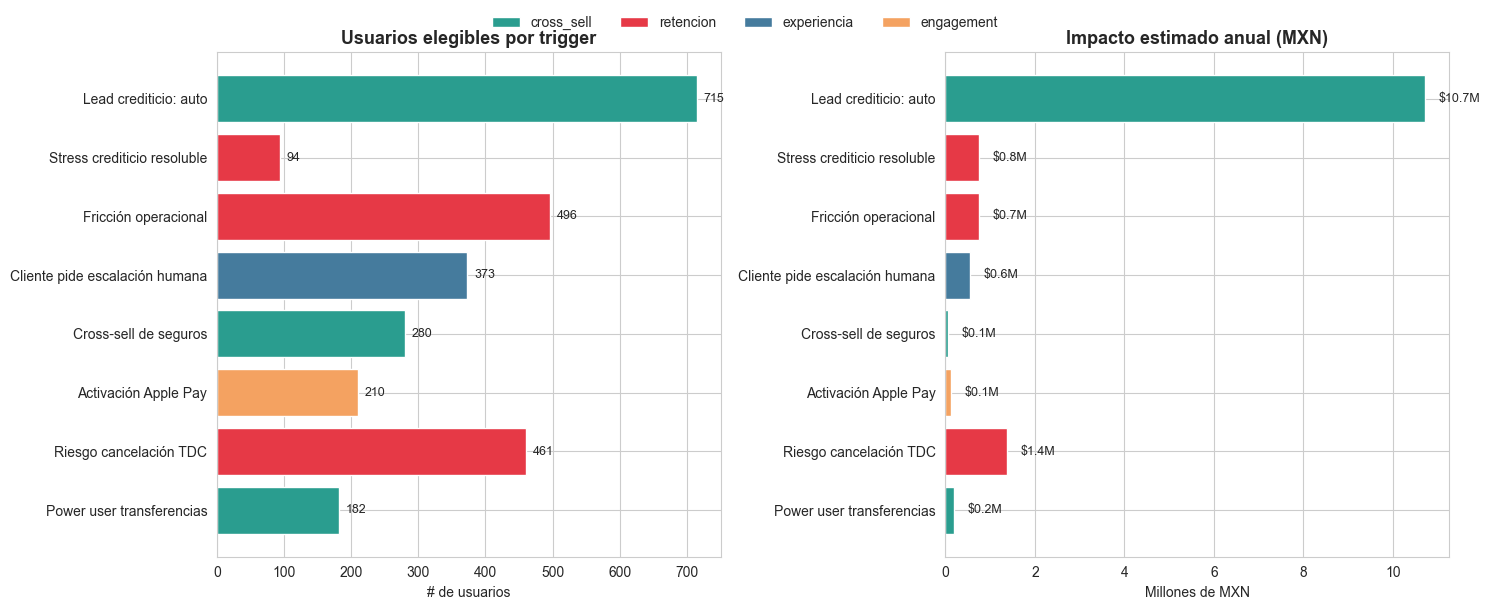

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Por tipo de trigger color
tipo_color = {'cross_sell':'#2A9D8F', 'retencion':'#E63946',
              'experiencia':'#457B9D', 'engagement':'#F4A261'}
colors = [tipo_color[t] for t in trigger_df['tipo']]

# Tamaños
axes[0].barh(trigger_df['nombre'], trigger_df['n_elegibles'], color=colors, edgecolor='white')
axes[0].set_title('Usuarios elegibles por trigger', fontsize=13, fontweight='bold')
axes[0].set_xlabel('# de usuarios')
axes[0].invert_yaxis()
for i, v in enumerate(trigger_df['n_elegibles']):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# Impacto $
axes[1].barh(trigger_df['nombre'], trigger_df['impacto_estimado_mxn']/1e6, color=colors, edgecolor='white')
axes[1].set_title('Impacto estimado anual (MXN)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Millones de MXN')
axes[1].invert_yaxis()
for i, v in enumerate(trigger_df['impacto_estimado_mxn']/1e6):
    axes[1].text(v + 0.3, i, f'${v:.1f}M', va='center', fontsize=9)

# Leyenda compartida
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tipo_color.items()]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=4, frameon=False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/triggers_resumen.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Asignación de "Next Best Action" por usuario

Para la demo: dado un `user_id`, qué triggers tiene activos y cuál es el **mensaje sugerido**. Si tiene varios, hay que priorizar.

**Regla de priorización:**
1. Retención > Cross-sell > Engagement > Experiencia (impacto $ por usuario más alto)
2. Dentro del mismo tipo, mayor `valor_promedio × conv_rate`

In [10]:
PRIORIDAD_TIPO = {'retencion': 1, 'cross_sell': 2, 'engagement': 3, 'experiencia': 4}

def priorizar_triggers(df_in):
    """Para cada usuario asigna el trigger #1 (más prioritario) si tiene alguno."""
    # Aplicar todas las máscaras
    masks = {tid: t['condicion'](df_in) for tid, t in TRIGGERS.items()}
    
    # Score por trigger (mayor = mejor)
    scores = {}
    for tid, t in TRIGGERS.items():
        score = (10 - PRIORIDAD_TIPO[t['tipo']]) * 1e9 + (t['valor_promedio_mxn'] * t['conv_rate_estimada'])
        scores[tid] = score
    
    # Para cada usuario, el trigger ganador
    next_action = pd.Series([None] * len(df_in), index=df_in.index, dtype=object)
    next_action_score = pd.Series([0.0] * len(df_in), index=df_in.index)
    
    for tid, mask in masks.items():
        # Solo asignar si el score actual es mayor que el ya asignado
        better = mask & (scores[tid] > next_action_score)
        next_action[better] = tid
        next_action_score[better] = scores[tid]
    
    return next_action

df['next_best_action'] = priorizar_triggers(df)
df['next_best_action_label'] = df['next_best_action'].map(
    {tid: t['nombre'] for tid, t in TRIGGERS.items()}
)
df['next_best_action_message'] = df['next_best_action'].map(
    {tid: t['mensaje'] for tid, t in TRIGGERS.items()}
)
df['next_best_action_tipo'] = df['next_best_action'].map(
    {tid: t['tipo'] for tid, t in TRIGGERS.items()}
)

print('Distribución de Next Best Action:')
print(df['next_best_action_label'].value_counts(dropna=False).to_string())

print(f'\nUsuarios sin trigger activo: {df["next_best_action"].isna().sum():,} '
      f'({100*df["next_best_action"].isna().mean():.1f}%)')

Distribución de Next Best Action:
next_best_action_label
NaN                               12214
Lead crediticio: auto               715
Fricción operacional                496
Riesgo cancelación TDC              461
Cliente pide escalación humana      373
Cross-sell de seguros               280
Activación Apple Pay                210
Power user transferencias           182
Stress crediticio resoluble          94

Usuarios sin trigger activo: 12,214 (81.3%)


---
## 6. Casos para usar en el pitch

Tres usuarios concretos que ilustran la propuesta. Útil para que la persona del pitch los memorice y haga la demo en vivo.

In [11]:
def mostrar_ficha(user_id):
    """Imprime ficha estilo demo para un usuario."""
    u = df[df['user_id'] == user_id].iloc[0]
    print(f'\n{"="*70}')
    print(f'  USUARIO: {user_id}')
    print(f'  {u["sexo"]}, {u["edad"]} años, {u["ciudad"]}, {u["estado"]}')
    print(f'  {u["ocupacion"]} · {u["nivel_educativo"]} · Ingreso ${u["ingreso_mensual_mxn"]:,.0f}')
    print(f'  Hey Pro: {u["es_hey_pro"]} · Antigüedad: {u["antiguedad_dias"]/365:.1f} años · NPS: {u["satisfaccion_1_10"]}/10')
    print(f'{"-"*70}')
    print(f'  📊 PERFIL COMPORTAMENTAL')
    print(f'     Categoría:        {u["categoria"]}')
    print(f'     Salud crediticia: {u["categoria_salud"]}')
    print(f'     Score buró:       {u["score_buro"]}')
    print(f'     Saldo actual:     ${u["saldo"]:,.0f}')
    print(f'     Transacciones:    {u["num_transacciones"]} (de las cuales {u["num_no_procesadas"]} no procesadas)')
    print(f'  💬 PERFIL CONVERSACIONAL (Havi)')
    print(f'     Tópico dominante: "{u["cluster_label_dominante"]}"')
    print(f'     Tópicos distintos: {u["num_clusters_distintos"]}')
    print(f'{"-"*70}')
    if pd.notna(u['next_best_action']):
        print(f'  🎯 NEXT BEST ACTION: {u["next_best_action_label"]}')
        print(f'     Tipo: {u["next_best_action_tipo"]}')
        print(f'\n     Mensaje sugerido:')
        print(f'     "{u["next_best_action_message"]}"')
    else:
        print(f'  ✅ Sin trigger activo — cliente saludable, mantener experiencia actual.')
    print(f'{"="*70}')


# Buscar 3 casos representativos para el pitch
# Caso 1: Lead caliente (T1)
caso1 = df[df['next_best_action'] == 'T1_lead_credito_auto'].sort_values('ingreso_mensual_mxn', ascending=False).iloc[0]
# Caso 2: Stress crediticio (T2)
caso2_pool = df[df['next_best_action'] == 'T2_stress_credito']
caso2 = caso2_pool.iloc[0] if len(caso2_pool) > 0 else df[df['next_best_action'] == 'T7_intercepta_cancelacion'].iloc[0]
# Caso 3: Cliente que pide ayuda humana (T4)
caso3 = df[df['next_best_action'] == 'T4_solicita_escalacion'].iloc[0]

print('TRES CASOS PARA EL PITCH:')
for caso in [caso1, caso2, caso3]:
    mostrar_ficha(caso['user_id'])

TRES CASOS PARA EL PITCH:

  USUARIO: USR-13759
  M, 53 años, San Pedro Tlaquepaque, Jalisco
  Empresario · Posgrado · Ingreso $99,000
  Hey Pro: False · Antigüedad: 1.7 años · NPS: 10.0/10
----------------------------------------------------------------------
  📊 PERFIL COMPORTAMENTAL
     Categoría:        Solo Débito
     Salud crediticia: Sin Información
     Score buró:       757
     Saldo actual:     $-215,772
     Transacciones:    44 (de las cuales 2.0 no procesadas)
  💬 PERFIL CONVERSACIONAL (Havi)
     Tópico dominante: "Cotización de crédito automotriz"
     Tópicos distintos: 1
----------------------------------------------------------------------
  🎯 NEXT BEST ACTION: Lead crediticio: auto
     Tipo: cross_sell

     Mensaje sugerido:
     "🚗 ¡Tu auto está más cerca de lo que crees! Tienes pre-aprobación para tu crédito automotriz. Cotiza con un click y conoce tu mensualidad."

  USUARIO: USR-00042
  M, 34 años, Córdoba, Veracruz
  Empleado · Preparatoria · Ingreso $18,00

---
## 7. Export final

Archivos para alimentar la demo de Streamlit y el deck del pitch.

In [12]:
# 1. Master final con next_best_action incluido
df.to_csv(f'{DATA_DIR}/df_clientes_con_triggers.csv', index=False)

# 2. Tabla de triggers (para slide del pitch)
trigger_df.to_csv(f'{DATA_DIR}/triggers_tabla.csv', index=False)

# 3. Cruces para visualización
cross_cat_pct.to_csv(f'{DATA_DIR}/cruce_categoria_topico_pct.csv')
cross_salud_pct.to_csv(f'{DATA_DIR}/cruce_salud_topico_pct.csv')

# 4. Diccionario de mensajes (para que la demo lo cargue)
mensajes_export = pd.DataFrame([
    {'trigger_id': tid, 'nombre': t['nombre'], 'tipo': t['tipo'],
     'accion': t['accion'], 'mensaje': t['mensaje']}
    for tid, t in TRIGGERS.items()
])
mensajes_export.to_csv(f'{DATA_DIR}/triggers_mensajes.csv', index=False)

print('Archivos generados:')
print(f'  ../data/df_clientes_con_triggers.csv     ({df.shape})')
print(f'  ../data/triggers_tabla.csv               ({trigger_df.shape})')
print(f'  ../data/cruce_categoria_topico_pct.csv   ({cross_cat_pct.shape})')
print(f'  ../data/cruce_salud_topico_pct.csv       ({cross_salud_pct.shape})')
print(f'  ../data/triggers_mensajes.csv            ({mensajes_export.shape})')
print(f'  ../outputs/heatmap_categoria_topico.png')
print(f'  ../outputs/heatmap_salud_topico.png')
print(f'  ../outputs/triggers_resumen.png')

Archivos generados:
  ../data/df_clientes_con_triggers.csv     ((15025, 51))
  ../data/triggers_tabla.csv               ((8, 8))
  ../data/cruce_categoria_topico_pct.csv   ((5, 15))
  ../data/cruce_salud_topico_pct.csv       ((6, 15))
  ../data/triggers_mensajes.csv            ((8, 5))
  ../outputs/heatmap_categoria_topico.png
  ../outputs/heatmap_salud_topico.png
  ../outputs/triggers_resumen.png


---
## 8. Insights para el pitch (lectura del cruce)

**Storytelling sugerido (al ver el heatmap categoría × tópico):**

1. *"Los **Débito + Crédito** verbalizan desproporcionadamente sobre 'Aumentar límite de transferencias' — son power users buscando upgrade. Oportunidad de Hey Pro."*

2. *"Los **Solo Débito** son los que más piden 'atención humana' — indica fricción de onboarding. Si los retenemos en este momento, los convertimos en Débito + Crédito."*

3. *"Los **Otros** verbalizan sobre 'Créditos personales y diferimientos' — perfil oculto de stress que el comportamiento no detectaba. Una segmentación sin Havi se los pierde."*

4. *"Los **Débito + Seguro** hablan de 'reposición de tarjeta' y 'estado de cuenta' — son cautelosos por naturaleza. Nuestra recomendación es no saturarlos con cross-sell agresivo."*

**Y al ver el heatmap de salud crediticia:**

5. *"El segmento **Endeudamiento Alto** habla de 'Créditos personales y diferimientos' — están literalmente pidiendo ayuda. Sin Havi solo veríamos su utilización al 90% y enviaríamos un cobranzas. Con Havi entendemos que quieren reestructurar — lead de retención de oro."*